# Initial Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit

In [2]:
tess_offset = 2457000

In [3]:
bootstrap = True

# Get Data

In [4]:
### Planet params 
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [5]:
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [6]:
if bootstrap == True:
    # bootstrap method
    df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
else:
    # no bootstrap method (chisq +1)
    df = pd.read_csv("toi_1339_transit_data_all_no_bootstrap.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_65166/131908810.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_65166/131908810.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all_no_bootstrap.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [7]:
print(df)

    Planet_num  Index           Tc    Tc_err
0            2      0  1726.054975  0.002286
1            2      1  1754.634044  0.001203
2            2      2  1783.211479  0.001701
3            2      3  1811.800043  0.001701
4            2      4  1840.375325  0.000472
5            2      6  1897.535247  0.002019
6            2      7  1926.116447  0.001668
7            2     25  2440.545208  0.001454
8            2     32  2640.606524  0.001926
9            2     34  2697.771841  0.001416
10           2     35  2726.353066  0.003117
11           2     38  2812.096804  0.002137
12           2     39  2840.672750  0.001203
13           2     42  2926.419096  0.001711
14           2     55  3297.970702  0.002137
15           2     57  3355.129798  0.000746
16           2     58  3383.710439  0.001180
17           2     60  3440.876620  0.001668
18           2     64  3555.195637  0.001203
19           2     65  3583.771809  0.001492
20           2     66  3612.350021  0.002170
21        

In [8]:
indices_2 = df[df['Planet_num'] == 2]['Index'].tolist()
transit_times_2 = df[df['Planet_num'] == 2]['Tc'].tolist()
tc_err_2 = df[df['Planet_num'] == 2]['Tc_err'].tolist()

indices_3 = df[df['Planet_num'] == 3]['Index'].tolist()
transit_times_3 = df[df['Planet_num'] == 3]['Tc'].tolist()
tc_err_3 = df[df['Planet_num'] == 3]['Tc_err'].tolist()


# OMC

In [9]:
# Define linear ephemeris function
def linear_ephem(E, T0, P):
    return T0 + P * E

# Function to compute O-C per planet
def compute_oc(df):
    df_all = []
    fit_params = []  # store fit results here

    for planet in df['Planet_num'].unique():
        planet_df = df[df['Planet_num'] == planet].copy()
        E = planet_df['Index'].values
        Tc_obs = planet_df['Tc'].values
        Tc_err = planet_df['Tc_err'].values

        # Fit linear ephemeris
        popt, pcov = curve_fit(linear_ephem, E, Tc_obs, sigma=Tc_err, absolute_sigma=True)
        T0, P = popt
        T0_err, P_err = np.sqrt(np.diag(pcov))

        Tc_calc = linear_ephem(E, T0, P)
        oc = Tc_obs - Tc_calc

        planet_df['Tcalc'] = Tc_calc
        planet_df['O-C'] = oc
        planet_df['Planet'] = planet
        df_all.append(planet_df)

        fit_params.append({
            'Planet_num': planet,
            'T0': T0,
            'T0_err': T0_err,
            'Period': P,
            'Period_err': P_err
        })

    return pd.concat(df_all), pd.DataFrame(fit_params)


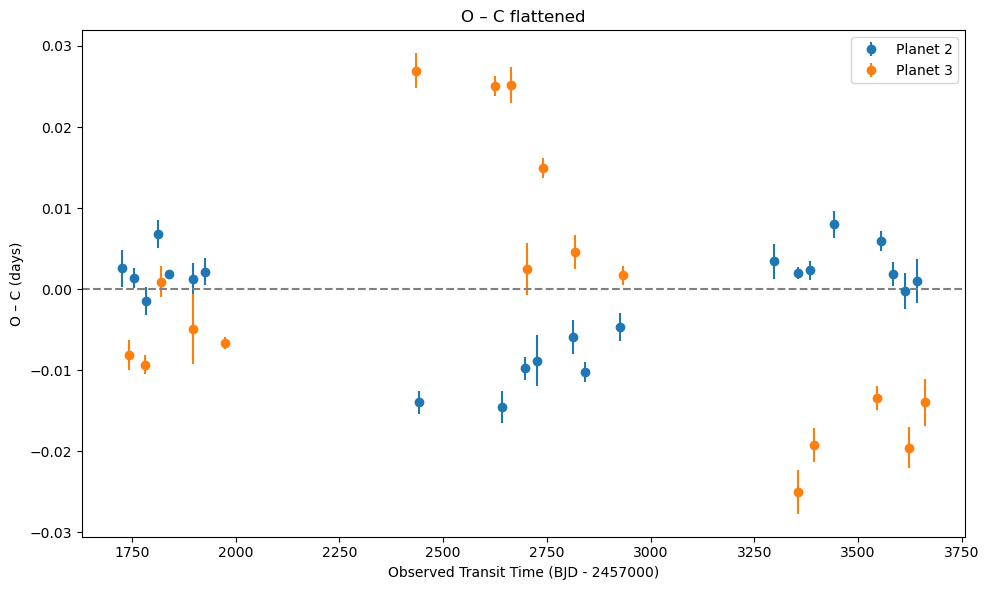

In [10]:
df_oc, ephem_df = compute_oc(df)

# Plot: O–C vs. Tc_obs for all planets
plt.figure(figsize=(10, 6))
for planet in df_oc['Planet_num'].unique():
    subset = df_oc[df_oc['Planet_num'] == planet]
    plt.errorbar(
        subset['Tc'], subset['O-C'], yerr=subset['Tc_err'],
        fmt='o', label=f'Planet {planet}'
    )

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(f"Observed Transit Time (BJD - {tess_offset})")
plt.ylabel("O – C (days)")
plt.title("O – C flattened")
plt.legend()
plt.tight_layout()
plt.show()

# Single Harmonic Sine Fit

In [11]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [12]:
print(ephem_df)


   Planet_num           T0    T0_err     Period  Period_err
0           2  1726.052433  0.000401  28.580270    0.000011
1           3  1743.560958  0.000603  38.351608    0.000024


In [13]:
j = 4 # 4:3 MMR
p_2 = ephem_df['Period'][0]
p_3 = ephem_df['Period'][1]
tc_2 = ephem_df['T0'][0]
tc_3 = ephem_df['T0'][1]


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006418267127810573
TTV period: 1493.8458884829531 days


In [14]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [15]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [16]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [17]:
from scipy.optimize import least_squares

indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)

indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)


### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72604617e+03  2.85803140e+01  7.98911624e-03  1.74357212e+03
  3.83512631e+01 -1.92443040e-02  1.53893063e+03  1.40959399e+03]


In [18]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [19]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04617425 ± 0.00054507
   P_b = 28.58031404 ± 0.00001169
  A_bc = 0.00798912 ± 0.00044841
  t_c0 = 1743.57212242 ± 0.00086355
   P_c = 38.35126309 ± 0.00003392
  A_cb = -0.01924430 ± 0.00064231
  P_cb = 1538.93062621 ± 25.94993711
 t_cb0 = 1409.59398746 ± 24.54034976


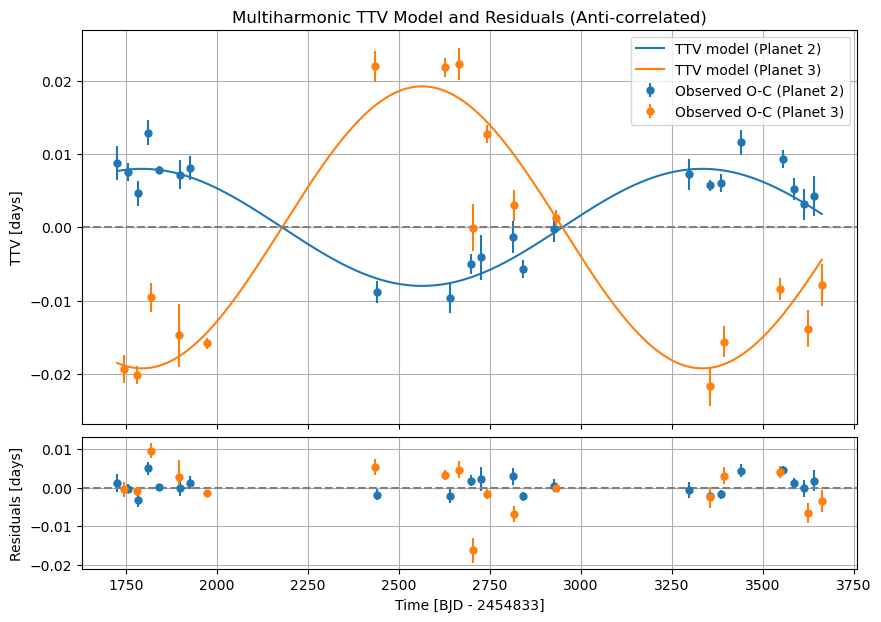

In [20]:
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) #* 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) #* 1440  

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) #* 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) #* 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) #* 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) #* 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [days]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [days]")
ax2.grid(True)

plt.show()

In [21]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1538.930626 ± 25.949937 days
A_23: 11.504159999999999 ± 0.64512 min
A_32: -27.711360000000003 ± 0.92448 min


# Save Data

In [22]:
import pickle

# Bundle all relevant data into a dictionary
ttv_data = {
    "tc_lin_obs_2": t_lin_obs_b,
    "tc_lin_obs_3": t_lin_obs_c,
    "omc_2": oc_b,
    "omc_3": oc_c,
    "ttv_model_2": ttv_model_b,
    "ttv_model_3": ttv_model_c,
    "residuals_2": residuals_b,
    "residuals_3": residuals_c,
    "tc_err_2": np.array(tc_err_2),
    "tc_err_3": np.array(tc_err_3),
    "indices_2": np.array(indices_2),
    "indices_3": np.array(indices_3),
    "t_dense": np.array(t_dense),
    "ttv_2": np.array(ttv_b),
    "ttv_3": np.array(ttv_c)
}

if bootstrap == True:
    # Save to a file
    with open("1339_sine_fit.pkl", "wb") as f:
        pickle.dump(ttv_data, f)

else:
    # Save to a file
    with open("1339_sine_fit_no_bootstrap.pkl", "wb") as f:
        pickle.dump(ttv_data, f)


# Following V1298Tau
procedure for planets c and d, where L12 model is not appropriate 

In [23]:
def P_lambda(P1, P2, P_tau, m1, m2, M_star, k, f1, f2):
    term1 = (P1+P2) / 2.
    term2 = P_tau / (2.*np.pi)
    term3 = ((m1 + m2) / M_star)**(-2./3.)
    term4 = ((3./2.) * k*(k-1)*np.abs(f1)*f2)**(-1./3.)
    P = term1 * term2 * term3 * term4
    return P

def A_1_(k, Lambda1, nu, P_tau, A_psi):
    term1_num = 3*(k-1)
    term1_den = Lambda1*nu
    term1 = term1_num / term1_den
    term2 = P_tau / (2*np.pi)
    A = term1 * term2 * A_psi
    return A

def A_2_(k, Lambda2, nu, P_tau, A_psi):
    term1 = (3*k) / (Lambda2*nu)
    term2 = P_tau / (2*np.pi)
    A = term1 * term2 * A_psi
    return A

def nu_(k, P1, P2, Lambda1, Lambda2):
    n1 = (2*np.pi) / P1
    n2 = (2*np.pi) / P2
    term1 = ((k-1)**2 * n1) / Lambda1
    term2 = (k**2 * n2) / Lambda2
    nu = (3./2.) * (term1 + term2)
    return nu

def Lambda_k(mk, a_k, M_star, G):
    lambda_k = mk* np.sqrt(G*M_star*a_k)
    return lambda_k
    

In [24]:
k=4
f1 = -2.840
f2 = 3.283
M_star = 0.81 # [solar mass]

from astropy.constants import G, M_sun
from astropy import units as u

# Gravitational constant in AU^3 / (Msun * day^2)
G_au = G.to(u.AU**3 / (u.M_sun * u.day**2))
G_const = G_au.value


In [25]:
# np.random.seed(42)

def log_uniform(low, high, size=None):
    return 10 ** np.random.uniform(np.log10(low), np.log10(high), size=size)

def uniform(low, high, size=None):
    return np.random.uniform(low, high, size=size)


In [26]:
P_ttv_obs = P_cb
sigma_P_ttv = P_cb_err
A1_obs = np.abs(A_bc)
sigma_A1 = A_bc_err
A2_obs = np.abs(A_cb)
sigma_A2 = A_cb_err
P1 = P_b
P2 = P_c

In [27]:
num_samples = 10000000

In [28]:
# Sample parameters
from astropy.constants import M_earth
Mearth_to_Msun = M_earth.value / M_sun.value
m1_samples = log_uniform(0.1, 40, num_samples) * Mearth_to_Msun  # convert to Msun
mass_ratio_samples = log_uniform(0.1, 2, num_samples)
m2_samples = m1_samples * mass_ratio_samples

e1_samples = log_uniform(1e-4, 1e-1, num_samples)
e2_samples = log_uniform(1e-4, 1e-1, num_samples)

sigma1_samples = uniform(0, 2*np.pi, num_samples)
sigma2_samples = uniform(0, 2*np.pi, num_samples)

P_tau_samples = uniform(2, 4, num_samples)
A_psi_samples = uniform(0, 1, num_samples)  # unknown libration amplitude


In [29]:
def semimajor_axis(P, M_star, G_const):
    return (G_const * M_star * (P/(2*np.pi))**2) ** (1/3)

a1 = semimajor_axis(P1, M_star, G_const)
a2 = semimajor_axis(P2, M_star, G_const)


In [30]:
# Compute Lambdas for each sample
Lambda1 = Lambda_k(m1_samples, a1, M_star, G_const)
Lambda2 = Lambda_k(m2_samples, a2, M_star, G_const)


In [31]:
nu_samples = nu_(k, P1, P2, Lambda1, Lambda2)

In [32]:
# Compute P_lambda for each sample
P_lambda_samples = P_lambda(P1, P2, P_tau_samples, m1_samples, m2_samples, M_star, k, f1, f2)


In [33]:
# Compute amplitudes for each sample
A1_samples = A_1_(k, Lambda1, nu_samples, P_tau_samples, A_psi_samples)
A2_samples = A_2_(k, Lambda2, nu_samples, P_tau_samples, A_psi_samples)


In [34]:
# Compute chi-square for each sample
chi2 = ((P_lambda_samples - P_ttv_obs)/sigma_P_ttv)**2 + \
       ((A1_samples - A1_obs)/sigma_A1)**2 + \
       ((A2_samples - A2_obs)/sigma_A2)**2
print(len(chi2[chi2<10]))

54


In [35]:
# Compute weights
weights = np.exp(-0.5 * chi2)

# Normalize weights
weights /= np.sum(weights)

# Calculate Effective Sample Size (ESS)
ESS = 1. / np.sum(weights**2)
print(f"Effective Sample Size (ESS): {ESS:.0f} out of {len(weights)} samples")


# Compute weighted parameter estimates, e.g. means and credible intervals
def weighted_quantile(values, quantiles, sample_weight):
    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]
    weighted_cdf = np.cumsum(sample_weight)
    weighted_cdf /= weighted_cdf[-1]
    return np.interp(quantiles, weighted_cdf, values)


Effective Sample Size (ESS): 18 out of 10000000 samples


In [36]:
# Quantiles for ±1σ around median
quantiles = [0.16, 0.50, 0.84]

# For m1
m1_q = weighted_quantile(m1_samples, quantiles, weights)
m1_median = m1_q[1]
m1_minus = m1_q[1] - m1_q[0]
m1_plus = m1_q[2] - m1_q[1]

# For m2
m2_q = weighted_quantile(m2_samples, quantiles, weights)
m2_median = m2_q[1]
m2_minus = m2_q[1] - m2_q[0]
m2_plus = m2_q[2] - m2_q[1]

# Convert to Earth masses if desired
m1_median_earth = m1_median / Mearth_to_Msun
m1_minus_earth = m1_minus / Mearth_to_Msun
m1_plus_earth = m1_plus / Mearth_to_Msun

m2_median_earth = m2_median / Mearth_to_Msun
m2_minus_earth = m2_minus / Mearth_to_Msun
m2_plus_earth = m2_plus / Mearth_to_Msun

print(f"m1 = {m1_median_earth:.2f} (+{m1_plus_earth:.2f} / -{m1_minus_earth:.2f}) M_earth")
print(f"m2 = {m2_median_earth:.2f} (+{m2_plus_earth:.2f} / -{m2_minus_earth:.2f}) M_earth")


m1 = 16.29 (+4.31 / -4.81) M_earth
m2 = 7.91 (+2.21 / -2.58) M_earth


In [37]:
m1_median = weighted_quantile(m1_samples, [0.5], weights)[0] / Mearth_to_Msun
m1_16 = weighted_quantile(m1_samples, [0.16], weights)[0] / Mearth_to_Msun
m1_84 = weighted_quantile(m1_samples, [0.84], weights)[0] / Mearth_to_Msun

m2_median = weighted_quantile(m2_samples, [0.5], weights)[0] / Mearth_to_Msun
m2_16 = weighted_quantile(m2_samples, [0.16], weights)[0] / Mearth_to_Msun
m2_84 = weighted_quantile(m2_samples, [0.84], weights)[0] / Mearth_to_Msun

print(f"m1 = {m1_median:.2f} (+{m1_84-m1_median:.2f}, -{m1_median-m1_16:.2f}) Earth masses")
print(f"m2 = {m2_median:.2f} (+{m2_84-m2_median:.2f}, -{m2_median-m2_16:.2f}) Earth masses")

m1 = 16.29 (+4.31, -4.81) Earth masses
m2 = 7.91 (+2.21, -2.58) Earth masses


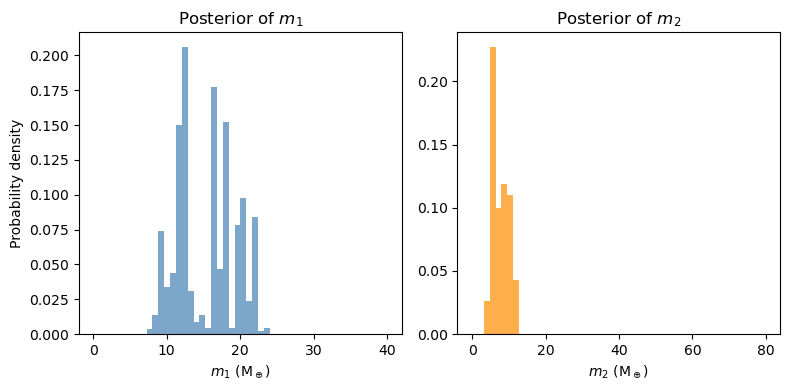

In [38]:
import matplotlib.pyplot as plt

# Convert to Earth masses
m1_plot = m1_samples / Mearth_to_Msun
m2_plot = m2_samples / Mearth_to_Msun

# Plot mass posterior for m1
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(m1_plot, bins=50, weights=weights, density=True, color='steelblue', alpha=0.7)
plt.xlabel(r"$m_1\ (\mathrm{M}_\oplus)$")
plt.ylabel("Probability density")
plt.title("Posterior of $m_1$")

# Plot mass posterior for m2
plt.subplot(1, 2, 2)
plt.hist(m2_plot, bins=50, weights=weights, density=True, color='darkorange', alpha=0.7)
plt.xlabel(r"$m_2\ (\mathrm{M}_\oplus)$")
plt.title("Posterior of $m_2$")

plt.tight_layout()
plt.show()


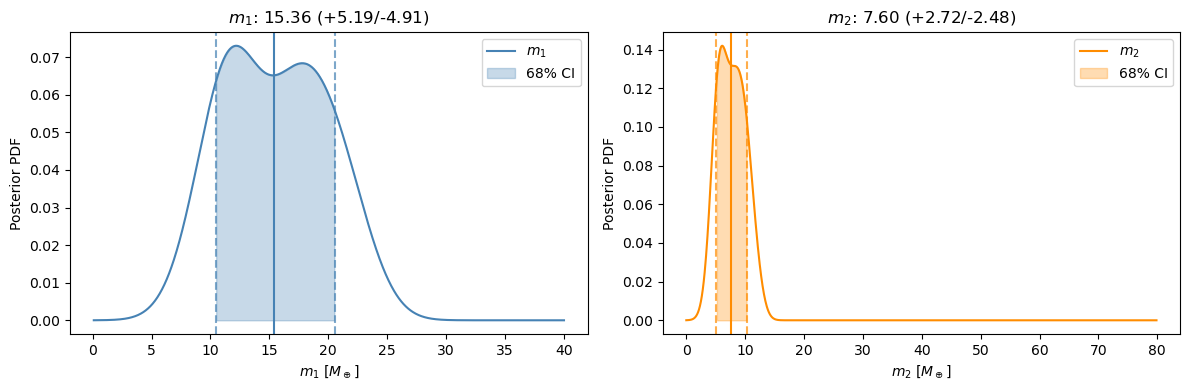

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_weighted_kde_with_ci(x, weights, label, color, ax):
    # Build weighted KDE
    kde = gaussian_kde(x, weights=weights)
    x_grid = np.linspace(np.min(x), np.max(x), 1000)
    pdf = kde(x_grid)

    # Normalize PDF
    pdf /= np.trapz(pdf, x_grid)

    # Compute CDF for confidence intervals
    cdf = np.cumsum(pdf) * (x_grid[1] - x_grid[0])

    # Compute 16th, 50th, 84th percentiles
    q16 = x_grid[np.searchsorted(cdf, 0.16)]
    q50 = x_grid[np.searchsorted(cdf, 0.50)]
    q84 = x_grid[np.searchsorted(cdf, 0.84)]

    # Plot KDE
    ax.plot(x_grid, pdf, color=color, label=label)
    ax.fill_between(x_grid, 0, pdf, where=(x_grid > q16) & (x_grid < q84), color=color, alpha=0.3, label='68% CI')

    # Plot vertical lines at quantiles
    ax.axvline(q16, color=color, linestyle='--', alpha=0.7)
    ax.axvline(q50, color=color, linestyle='-')
    ax.axvline(q84, color=color, linestyle='--', alpha=0.7)

    # Annotate median
    ax.set_title(f"{label}: {q50:.2f} (+{q84 - q50:.2f}/-{q50 - q16:.2f})")
    ax.set_xlabel(f"{label} [$M_\\oplus$]")
    ax.set_ylabel("Posterior PDF")
    ax.legend()

# Convert samples to Earth masses
m1_plot = m1_samples / Mearth_to_Msun
m2_plot = m2_samples / Mearth_to_Msun

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_weighted_kde_with_ci(m1_plot, weights, r"$m_1$", "steelblue", axs[0])
plot_weighted_kde_with_ci(m2_plot, weights, r"$m_2$", "darkorange", axs[1])

plt.tight_layout()
plt.show()


# Synodic chopping signal calculation

# try mcmc :(

In [40]:
def log_prior(theta):
    m1, mass_ratio, P_tau, A_psi = theta
    if 0.1 < m1 < 40 and 0.5 < mass_ratio < 2 and 2 < P_tau < 4 and 0 <= A_psi <= 1:
        return 0.0
    return -np.inf

# Log-likelihood function
def log_likelihood(theta, P1, P2, P_ttv_obs, sigma_P_ttv, A1_obs, sigma_A1, A2_obs, sigma_A2, M_star, k, f1, f2, G_const, a1, a2):
    m1, mass_ratio, P_tau, A_psi = theta
    m2 = m1 * mass_ratio
    
    # Convert Earth masses to Msun
    m1_Msun = m1 * Mearth_to_Msun
    m2_Msun = m2 * Mearth_to_Msun

    Lambda1 = Lambda_k(m1_Msun, a1, M_star, G_const)
    Lambda2 = Lambda_k(m2_Msun, a2, M_star, G_const)
    nu = nu_(k, P1, P2, Lambda1, Lambda2)

    P_ttv_model = P_lambda(P1, P2, P_tau, m1_Msun, m2_Msun, M_star, k, f1, f2)
    A1_model = A_1_(k, Lambda1, nu, P_tau, A_psi)
    A2_model = A_2_(k, Lambda2, nu, P_tau, A_psi)

    chi2 = ((P_ttv_model - P_ttv_obs)**2 / sigma_P_ttv**2
            + (A1_model - A1_obs)**2 / sigma_A1**2
            + (A2_model - A2_obs)**2 / sigma_A2**2)
    return -0.5 * chi2

# Log-probability function
def log_probability(theta, *args):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, *args)


In [41]:
# Initial guess and MCMC setup
initial = np.array([6, 0.3, 3.0, 0.5]) #m1, mass_ratio, P_tau, A_psi = theta

ndim = len(initial)
nwalkers = 32
nsteps = 1000000

pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)


In [42]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [43]:
# Run MCMC
import emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability,
                                args=(P1, P2, P_ttv_obs, sigma_P_ttv, A1_obs, sigma_A1,
                                      A2_obs, sigma_A2, M_star, k, f1, f2, G_const, a1, a2))


In [44]:
print("Running MCMC...")
sampler.run_mcmc(pos, nsteps, progress=True)


Running MCMC...


  0%|                                               | 0/1000000 [00:00<?, ?it/s]/opt/homebrew/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████| 1000000/1000000 [02:53<00:00, 5765.33it/s]


State([[5.99990233 0.29996705 3.0000151  0.49997308]
 [6.0000902  0.29994306 3.00016461 0.50006387]
 [5.99984992 0.30004822 2.99985232 0.50013613]
 [6.00000618 0.29984216 2.99983915 0.50001443]
 [6.00005461 0.30003171 2.99998811 0.49996989]
 [6.00004106 0.30002132 3.00004321 0.50004284]
 [5.9998663  0.29998001 2.99990519 0.50001704]
 [6.00005828 0.29986549 3.00008832 0.49990804]
 [6.00010301 0.30019456 3.00001235 0.50012338]
 [5.99991264 0.29998775 2.99999749 0.50011623]
 [5.99994634 0.29980933 2.99995453 0.49983218]
 [5.99992696 0.30008076 2.99999643 0.50014004]
 [5.99998745 0.30014041 3.00001921 0.50019447]
 [5.99977993 0.30003193 3.00000126 0.49997832]
 [6.00001226 0.30006069 3.00016203 0.5000504 ]
 [6.00010644 0.30004965 2.99994275 0.49992667]
 [5.9999575  0.30002368 3.00001316 0.49985129]
 [6.00006813 0.29995152 2.99981098 0.50007844]
 [6.00002492 0.30012943 2.99996751 0.50000481]
 [5.99998167 0.2999658  3.00011878 0.49999772]
 [6.00001266 0.29994928 3.00014956 0.4999614 ]
 [5.999

In [45]:
samples = sampler.get_chain(discard=1000, thin=15, flat=True)


In [46]:
# Extract posterior samples
m1_samples = samples[:,0]
mass_ratio_samples = samples[:,1]
m2_samples = m1_samples * mass_ratio_samples


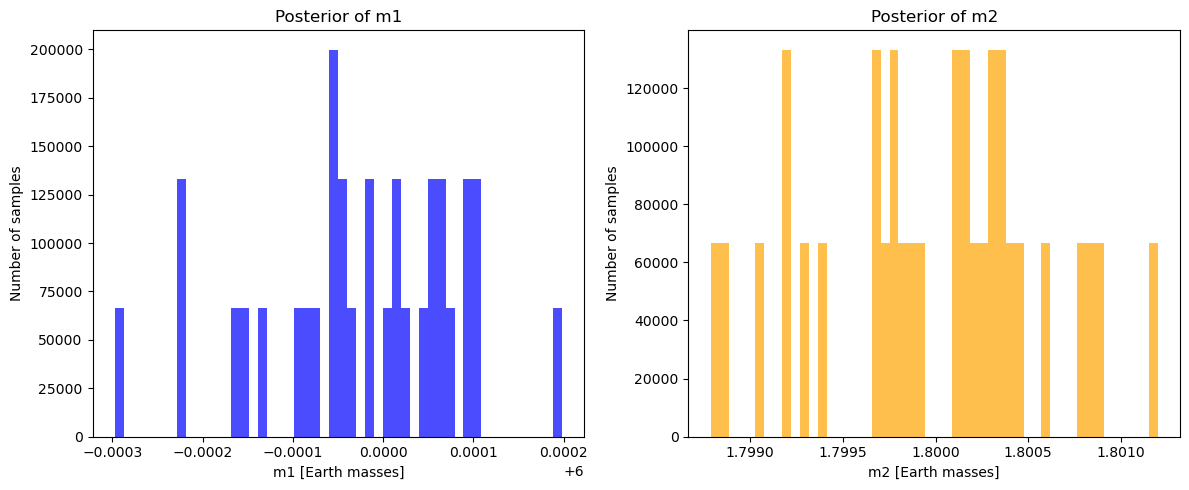

In [47]:
# Plotting posterior distributions
fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].hist(m1_samples, bins=50, color='blue', alpha=0.7)
axs[0].set_xlabel('m1 [Earth masses]')
axs[0].set_ylabel('Number of samples')
axs[0].set_title('Posterior of m1')

axs[1].hist(m2_samples, bins=50, color='orange', alpha=0.7)
axs[1].set_xlabel('m2 [Earth masses]')
axs[1].set_ylabel('Number of samples')
axs[1].set_title('Posterior of m2')

plt.tight_layout()
plt.show()